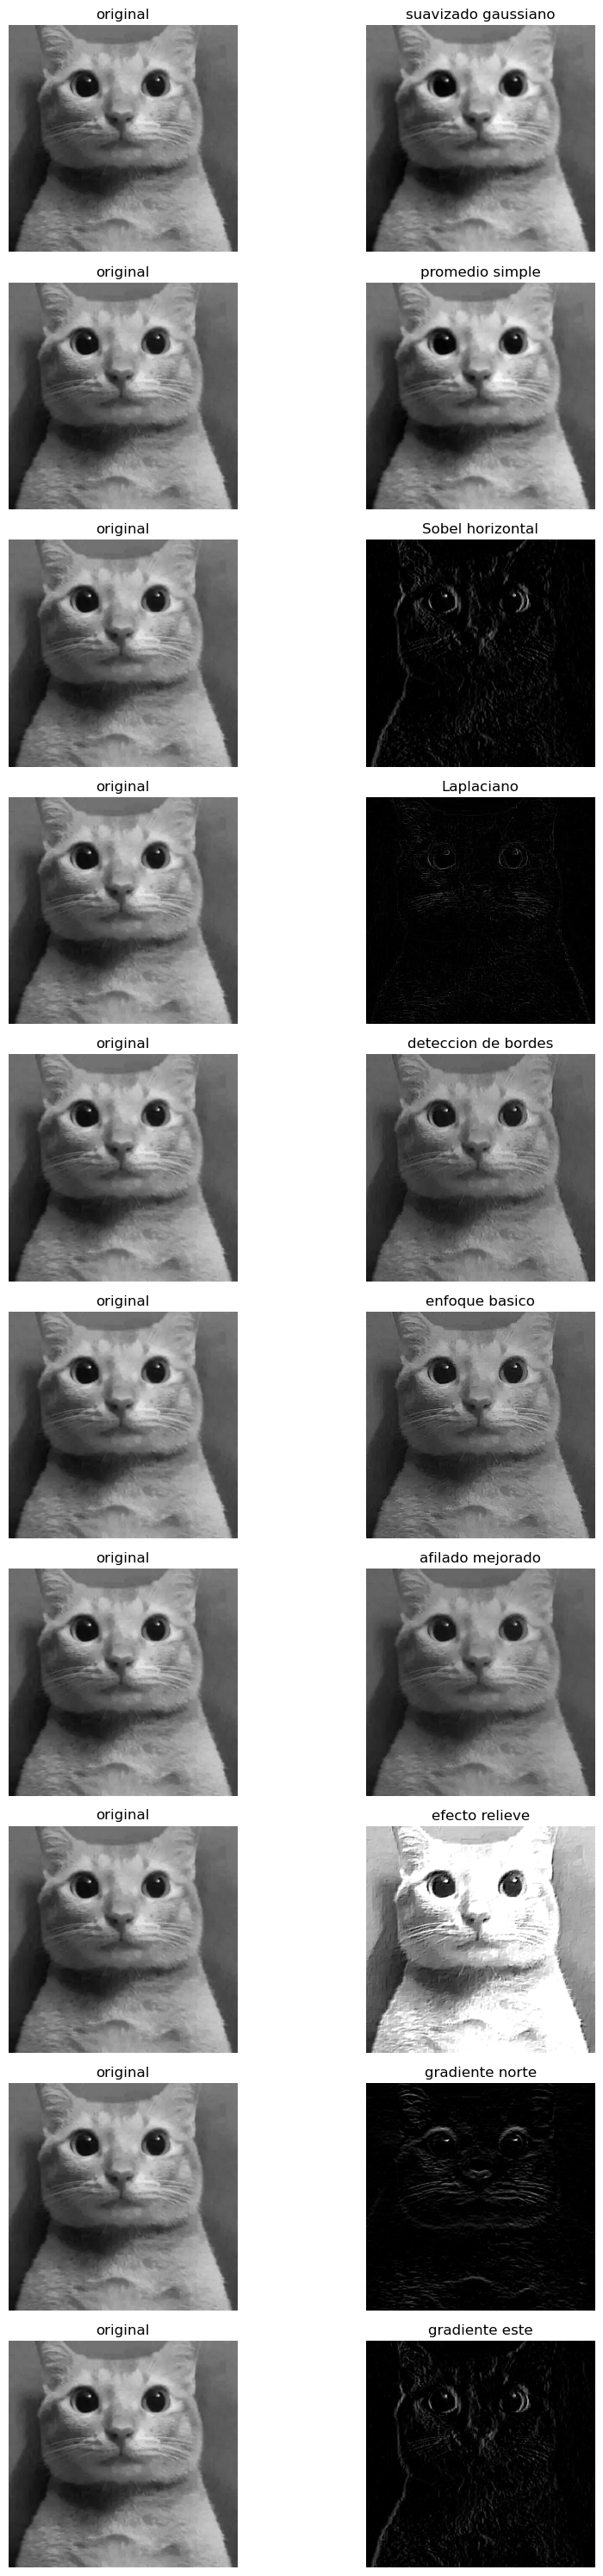

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('gato.jpg', 0)

# Suavizado gaussiano (normalizado)
k_gauss = np.array([[1,2,3,1,1],[2,7,11,7,2],[3,11,17,11,3],[2,7,11,7,1],[1,2,3,2,1]], dtype=np.float32)
k_gauss = k_gauss / k_gauss.sum()
res_gauss = cv2.filter2D(imagen, -1, k_gauss)

# Promedio simple (normalizado)
k_promedio = np.array([[1,1,1],[1,1,1],[1,1,1]], dtype=np.float32) / 9
res_promedio = cv2.filter2D(imagen, -1, k_promedio)

# Sobel horizontal
k_sobel = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
res_sobel = cv2.filter2D(imagen, -1, k_sobel)

# Laplaciano
k_laplace = np.array([[0,1,0],[1,-4,1],[0,1,0]])
res_laplace = cv2.filter2D(imagen, -1, k_laplace)

# Deteccion de bordes simple
k_borde = np.array([[0,0,0],[-1,1,1],[0,0,0]])
res_borde = cv2.filter2D(imagen, -1, k_borde)

# Enfoque basico
k_enfoque = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
res_enfoque = cv2.filter2D(imagen, -1, k_enfoque)

# Afilado mejorado
k_afilado = np.array([[1,-2,1],[-2,5,-2],[1,-2,1]])
res_afilado = cv2.filter2D(imagen, -1, k_afilado)

# Efecto relieve
k_relieve = np.array([[-2,-1,0],[-1,1,2],[0,1,2]])
res_relieve = cv2.filter2D(imagen, -1, k_relieve)

# Gradiente norte
k_norte = np.array([[1,1,1],[1,-2,1],[-1,-1,-1]])
res_norte = cv2.filter2D(imagen, -1, k_norte)

# Gradiente este
k_este = np.array([[-1,1,1],[-1,-2,1],[-1,1,1]])
res_este = cv2.filter2D(imagen, -1, k_este)

resultados = [res_gauss, res_promedio, res_sobel, res_laplace, res_borde,
              res_enfoque, res_afilado, res_relieve, res_norte, res_este]
etiquetas = [
    'suavizado gaussiano',
    'promedio simple',
    'Sobel horizontal',
    'Laplaciano',
    'deteccion de bordes',
    'enfoque basico',
    'afilado mejorado',
    'efecto relieve',
    'gradiente norte',
    'gradiente este'
]

total = len(resultados)
fig, ejes = plt.subplots(total, 2, figsize=(10, 3 * total))

for i, (filtrada, etiqueta) in enumerate(zip(resultados, etiquetas)):
    ejes[i, 0].imshow(imagen, cmap='gray')
    ejes[i, 0].set_title('original')
    ejes[i, 0].axis('off')

    ejes[i, 1].imshow(filtrada, cmap='gray')
    ejes[i, 1].set_title(etiqueta)
    ejes[i, 1].axis('off')

plt.tight_layout()
plt.show()